# Import Packages 

In [177]:
import networkx as nx
import pandas as pd
import numpy as np
from enum import Enum
import time
import matplotlib.pyplot as plt

# Create Graph from Pixels

In [178]:
class Connection_types(Enum):
    Empty = 0
    Point = 1
    Up = 2
    Right = 3
    Down = 4
    Left = 5
    UpRight = 6
    DownRight = 7
    DownLeft = 8
    UpLeft = 9

connection_traversal_map: dict[int, tuple] = {
    Connection_types.Empty: (0,0),
    Connection_types.Point: (0,0),
    Connection_types.Up: (0, -1),
    Connection_types.Right: (1, 0),
    Connection_types.Down: (0, 1),
    Connection_types.Left: (-1, 0),
    Connection_types.UpRight: (1, -1),
    Connection_types.DownRight: (1, 1),
    Connection_types.DownLeft: (-1, 1),
    Connection_types.UpLeft: (-1, -1)
}
traversal_distance_map: dict[int, float] = {
    Connection_types.Empty: np.sqrt(np.pow(connection_traversal_map[Connection_types.Empty][0],2) + np.pow(connection_traversal_map[Connection_types.Empty][1],2)),
    Connection_types.Point: np.sqrt(np.pow(connection_traversal_map[Connection_types.Point][0],2) + np.pow(connection_traversal_map[Connection_types.Point][1],2)),
    Connection_types.Up: np.sqrt(np.pow(connection_traversal_map[Connection_types.Up][0],2) + np.pow(connection_traversal_map[Connection_types.Up][1],2)),
    Connection_types.Right: np.sqrt(np.pow(connection_traversal_map[Connection_types.Right][0],2) + np.pow(connection_traversal_map[Connection_types.Right][1],2)),
    Connection_types.Down: np.sqrt(np.pow(connection_traversal_map[Connection_types.Down][0],2) + np.pow(connection_traversal_map[Connection_types.Down][1],2)),
    Connection_types.Left: np.sqrt(np.pow(connection_traversal_map[Connection_types.Left][0],2) + np.pow(connection_traversal_map[Connection_types.Left][1],2)),
    Connection_types.UpRight: np.sqrt(np.pow(connection_traversal_map[Connection_types.UpRight][0],2) + np.pow(connection_traversal_map[Connection_types.UpRight][1],2)),
    Connection_types.DownRight: np.sqrt(np.pow(connection_traversal_map[Connection_types.DownRight][0],2) + np.pow(connection_traversal_map[Connection_types.DownRight][1],2)),
    Connection_types.DownLeft: np.sqrt(np.pow(connection_traversal_map[Connection_types.DownLeft][0],2) + np.pow(connection_traversal_map[Connection_types.DownLeft][1],2)),
    Connection_types.UpLeft: np.sqrt(np.pow(connection_traversal_map[Connection_types.UpLeft][0],2) + np.pow(connection_traversal_map[Connection_types.UpLeft][1],2)),
}

opposite_connection: dict[Enum, Enum] = {
    Connection_types.Up: Connection_types.Down,
    Connection_types.Right: Connection_types.Left,
    Connection_types.Down: Connection_types.Up,
    Connection_types.Left: Connection_types.Right,
    Connection_types.UpRight: Connection_types.DownLeft,
    Connection_types.DownRight: Connection_types.UpLeft,
    Connection_types.DownLeft: Connection_types.UpRight,
    Connection_types.UpLeft: Connection_types.DownRight
}


# In the C implementation the lists inside the matrix have a max length of 8 (all directions)
"""
      x 0 1 2 3 4 5
     y  ___________
     0 |0 - - - 0 
     1 ||   0 0 | 0
     2 || 0   | | 0
     3 || 0 - 0 0 |
     4 |0 - - 0 0 0
"""
test_direction_grid_6x5: list[list[set[Connection_types]]] = [
    # X
    [
        # Y
        {Connection_types.Down, Connection_types.Right},
        {Connection_types.Up, Connection_types.Down},
        {Connection_types.Up, Connection_types.Down},
        {Connection_types.Up, Connection_types.Down},
        {Connection_types.Up, Connection_types.Right},
        ],
    [
        {Connection_types.Left, Connection_types.Right},
        {Connection_types.Empty},
        {Connection_types.UpRight, Connection_types.Down},
        {Connection_types.Up, Connection_types.Right},
        {Connection_types.Left, Connection_types.Right},
        ],
    [
        {Connection_types.Left, Connection_types.Right},
        {Connection_types.DownLeft, Connection_types.Right},
        {Connection_types.Empty},
        {Connection_types.Left, Connection_types.Right},
        {Connection_types.Left, Connection_types.Right},
        ],
    [
        {Connection_types.Left, Connection_types.Right},
        {Connection_types.Left, Connection_types.Down},
        {Connection_types.Up, Connection_types.Down},
        {Connection_types.Up, Connection_types.Left, Connection_types.Right},
        {Connection_types.Left},
        ],
    [
        {Connection_types.Left, Connection_types.Down, Connection_types.DownRight},
        {Connection_types.Up, Connection_types.Down},
        {Connection_types.Up, Connection_types.Down},
        {Connection_types.Up},
        {Connection_types.Point},
        ],
    [
        {Connection_types.Empty},
        {Connection_types.UpLeft},
        {Connection_types.Down},
        {Connection_types.Up, Connection_types.Down},
        {Connection_types.Up},
        ],
]

In [179]:
print(Connection_types.Down._value_)

4


In [180]:
for idx_x, x_array in enumerate(test_direction_grid_6x5):
    for idx_y, y_array in enumerate(x_array):
        print(str(sum(map(lambda x: x.value, test_direction_grid_6x5[idx_x][idx_y]))) + ", ", end="") # f"({idx_y}, {idx_x}),"
    print()

7, 6, 6, 6, 5, 
8, 0, 10, 5, 8, 
8, 11, 0, 8, 8, 
8, 9, 6, 10, 5, 
16, 6, 6, 2, 1, 
0, 9, 4, 6, 2, 


In [181]:
a = (1,0)
b = (0,1)
print((a[0]+b[0], a[1]+b[1]))

(1, 1)


In [182]:
def add_xy(tuple_1: tuple[int, int], tuple_2: tuple[int, int]):
    return (tuple_1[0] + tuple_2[0], tuple_1[1] + tuple_2[1])

def sub_xy(tuple_1: tuple[int, int], tuple_2: tuple[int, int]):
    return (tuple_1[0] - tuple_2[0], tuple_1[1] - tuple_2[1])

def euc_dist_xy(tuple_1: tuple[int, int], tuple_2: tuple[int, int]):
    x_delta, y_delta = sub_xy(tuple_1, tuple_2)
    return np.sqrt(np.pow(x_delta, 2) + np.pow(y_delta, 2))

## Path traversal of pixels to be Drawn -> Graph

In [ ]:
# Function(s): 
# Generates a node list with positions
# Describe connections between noedes with an edgelist
# Weight the edgelist by distance between nodes.


def is_vertex(enum_set: set[Connection_types]) -> bool:
    connection_direction_list: set[Connection_types] = [Connection_types.Up, Connection_types.Right, Connection_types.UpRight, Connection_types.DownRight]
    if Connection_types.Empty in enum_set:
        # An empty cell cannot have a drawn vertex
        # print("Cell is Empty!")
        return False
    if Connection_types.Point in enum_set:
        # A cell with a point must be a vertex, that is unconnected.
        # print("Cell is a Point!")
        return True
    # If there are multiple pairs of directions through a cell, there should be a vertex (i.e. there are more than three unique lines out of the center of a cell)
    if enum_set.__len__() >= 3:
        return True
    for connection_direction in connection_direction_list:
        # If a cell has a diection in but not out it must be a vertex
        # If it has the direction in and out or neither it is not necessarily a vertex
        if (connection_direction in enum_set) ^ (opposite_connection[connection_direction] in enum_set):
            # print("Cell has direction in but not out, or vice versa!", connection_direction.name)
            # print("connection_direction in enum_set:", connection_direction in enum_set)
            # print("opposite_connection[connection_direction] in enum_set:", opposite_connection[connection_direction] in enum_set)
            return True
    return False

def get_connected_vertex(
        vertex_pos: tuple[int, int],
        direction_grid: list[list[set[Connection_types]]], 
        direction_search: None | tuple[int, int] = None,
        known_vertex_pos: set[tuple[int, int]] = set([]),
        vertex_set: set[tuple[int, int]] = set([])
        ) -> set[str]:
    
    # returns a set of vertex positions of nodes connected to the node at the initial entry position
    if direction_search:
        # print(vertex_pos, "-> ", end="")
        if direction_search in direction_grid[vertex_pos[0]][vertex_pos[1]] and (vertex_pos not in known_vertex_pos):
            next_position: tuple[int, int] = add_xy(vertex_pos, connection_traversal_map[direction_search])
            if opposite_connection[direction_search] not in direction_grid[next_position[0]][next_position[1]]:
                ValueError(f"The node {next_position}, doesn't point back at {vertex_pos}!")
            vertex_set = get_connected_vertex(
                vertex_pos=next_position,
                direction_grid=direction_grid,
                direction_search=direction_search,
                vertex_set=vertex_set,
                known_vertex_pos=known_vertex_pos
            )
        else:
            # print("*")
            vertex_set.add(vertex_pos)
    if direction_search == None:
        for direction in direction_grid[vertex_pos[0]][vertex_pos[1]]:
            # print(vertex_pos, "-> ", end="")
            vertex_set = get_connected_vertex(
                vertex_pos=add_xy(vertex_pos, connection_traversal_map[direction]),
                direction_grid=direction_grid,
                direction_search=direction,
                vertex_set=vertex_set,
                known_vertex_pos=known_vertex_pos
            )
    return vertex_set


def traverse_grid(direction_grid: list[list[set[Connection_types]]]):
    x_len: int = len(direction_grid)
    y_len: int = len(direction_grid[0])
    G: nx.Graph = nx.Graph()

    node_list: list[str] = []
    pos: dict[str, tuple[int, int]] = {}
    labels: dict[str, str] = {}

    for idx_y in range(y_len):
        for idx_x in range(x_len):
            if is_vertex(direction_grid[idx_x][idx_y]):
                label = f"{idx_x},{idx_y}"
                # node_idx = (idx_x)*y_len + idx_y
                node_list.append(label)
                pos[label] = (idx_x, idx_y)
                labels[label] = label
    
    weighted_edge_list: list[tuple[str, str, float]] = []

    for idx, vertex_name in enumerate(node_list):
        # print(vertex_name, ":")
        vertex_set = get_connected_vertex(
                vertex_pos=pos[vertex_name],
                direction_grid=direction_grid,
                known_vertex_pos=set(pos.values()),
                vertex_set=set([]),
        )
        vertex_dest_name_set: set[str] = set(map(lambda x: f"{x[0]},{x[1]}", vertex_set))
        # print("\t", vertex_dest_name_set)
        for vertex_hit_dest_name in vertex_dest_name_set:
            """
            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=[(vertex_name, vertex_hit_dest_name)],
                width=8,
                alpha=0.5,
                edge_color="tab:blue",
            )
            """
            edge = (
                vertex_name,
                vertex_hit_dest_name,
                euc_dist_xy(pos[vertex_name], pos[vertex_hit_dest_name])
            )
            weighted_edge_list.append(edge)

    fig, ax = plt.subplots(1,2, figsize=(14,6))
    nx.draw_networkx_nodes(G, pos, nodelist=node_list, node_color="tab:red", ax=ax[0])
    nx.draw_networkx_labels(G, pos, labels, font_size=12, font_color="whitesmoke", ax=ax[0])
    nx.draw_networkx_edges(
                G,
                pos,
                edgelist=weighted_edge_list,
                width=8,
                alpha=0.5,
                edge_color="tab:blue",
                ax=ax[0]
            )
    
    G.add_weighted_edges_from(weighted_edge_list)
    print(G.edges())
    
    nx.draw(G, ax=ax[1])
    plt.show()
    


[('0,0', '4,0'), ('0,0', '0,4'), ('4,0', '5,1'), ('4,0', '4,3'), ('0,4', '3,4'), ('4,3', '3,3'), ('2,1', '3,1'), ('2,1', '1,2'), ('3,1', '3,3'), ('1,2', '1,3'), ('3,3', '1,3'), ('5,2', '5,4'), ('4,4', '4,4')]


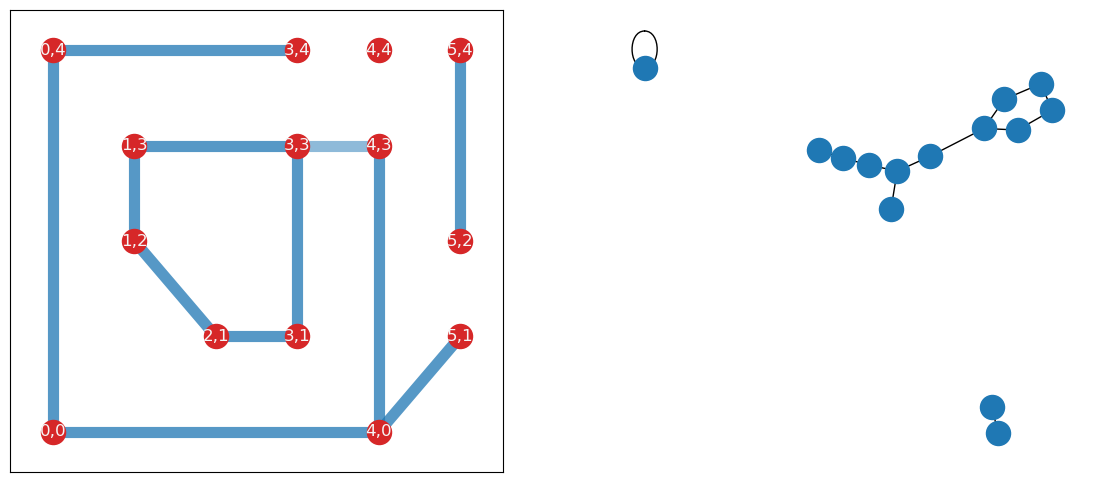

In [184]:
traverse_grid(test_direction_grid_6x5)

### Testing code

In [185]:
a=(0,1)
b=(0,5)
euc_dist_xy(a,b)

np.float64(4.0)

In [186]:

search_vertex_list = [(3,3), (4,0), (5,1), (2,1)]
for search_vertex in search_vertex_list:
    known_vertex_set = {3,3}
    vertex_set = get_connected_vertex(
        vertex_pos=search_vertex,
        direction_grid=test_direction_grid_6x5,
        known_vertex_pos=known_vertex_set,
        vertex_set=set([])
    )

    for y in range(len(test_direction_grid_6x5[0])):
        for x in range(len(test_direction_grid_6x5)):
            if (x, y) in vertex_set:
                prt_str = "@"
            elif (x,y) == search_vertex:
                prt_str = "*"
            else:
                prt_str = "-"
            print(prt_str, end=" ")
        print()
    print()

- - - - - - 
- - - @ - - 
- - - - - - 
- @ - * @ - 
- - - - - - 

@ - - - * - 
- - - - - @ 
- - - - - - 
- - - - @ - 
- - - - - - 

- - - - @ - 
- - - - - * 
- - - - - - 
- - - - - - 
- - - - - - 

- - - - - - 
- - * @ - - 
- @ - - - - 
- - - - - - 
- - - - - - 



# Generate the Joined Array from Individual Letters

In [187]:
char_dict_5x5: dict[str, np.array] = {
    "@": nx.from_edgelist([
        ("1,1", ""),
    ])
}

In [188]:
G = nx.from_numpy_array()
nx.draw(G)

TypeError: from_numpy_array() missing 1 required positional argument: 'A'